# 真实数据与封存记录
## 当前结论
本页从本机研究输入计算记录规模、回合恢复、观察时间和字段可用性，只展示聚合结果。
最终人工核验作为已封存的方法记录读取，展示其状态与判定规则。

## 范围与方法
原始子集为每行问答记录中的**首个文本问题**。另用行内 Q/A 标记恢复候选回合，每个 CSV 行是一个候选会话，不跨行拼接。
25f 的范围为 `[2025-09-01, 2026-03-01)`，26s 为 `[2026-03-01, 2026-09-01)`；
26s 同时按提供的学生名单筛选。去除重复行、无文本或仅链接的提问。
### 关键假设
名单是范围筛选条件；学生数按本地哈希标识去重，各学期人数不应直接相加为跨期去重总人数。
过滤诊断可能重叠，因此不绘制把所有排除原因相加的漏斗图。
Q/A 角色由结构标记推断，逐回合时间未知；候选会话不能直接解释为完整连续互动。

<!-- concept-illustration-v1:evidence-chain -->
### 证据追溯

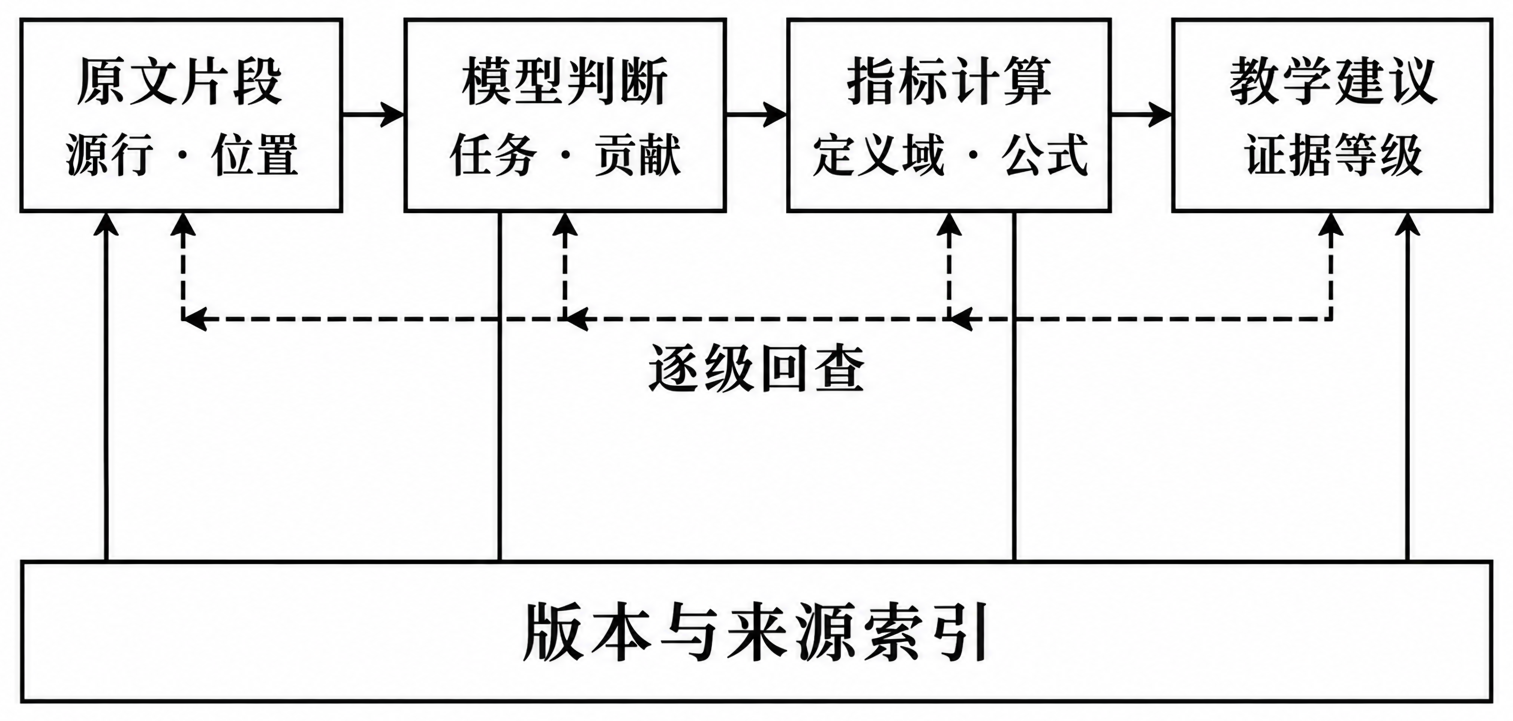

来源位置与版本将原文、判断、计算和建议连接起来。回查须核对各层适用条件；材料本身只允许在相应授权范围内读取。

In [1]:
from pathlib import Path
import sys, json
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "aiv").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from aiv.notebook_materials import (
    configure_style, save_figure, export_table, research_inputs,
    final_archive_summary, load_frozen_batch, load_turn_snapshot, load_turn_plan, load_full_turn_materials,
    turn_manifest_summary, pending_results, offline_monthly, COLORS,
)
configure_style()
LIVE_API = False

## 数据与来源校验

In [2]:
evidence = research_inputs()
SOURCES = ["runtime/research/records.json", "runtime/research/data-audit.json"]
if evidence is None:
    display(Markdown("**待接入：本机没有私有文本索引及审计文件。以下真实数据图保持空白。**"))
else:
    display(evidence["terms"])
    display(pd.DataFrame(evidence["sources"]))
    export_table(evidence["terms"], "real-term-summary")
    display(Markdown(f"共 **{evidence['terms'].text_records.sum():,} 条**文本记录，跨学期去重后 **{evidence['unique_students_all_terms']} 个**学生标识。输入的原始文件哈希与过滤记录数量已校验。"))

**待接入：本机没有私有文本索引及审计文件。以下真实数据图保持空白。**

## 从原始记录到候选回合

In [3]:
turns = turn_manifest_summary()
if turns is None:
    display(Markdown("**待接入：多轮解析清单不存在。**"))
else:
    counts = turns["counts"]
    recovery = pd.DataFrame([
        {"单位": "选入的原始 CSV 行", "数量": counts["selected_records"], "解释": "记录，非回合"},
        {"单位": "学生 Q 回合", "数量": counts["student_turns"], "解释": "含结构待核的学生文本"},
        {"单位": "可测评学生回合", "数量": counts["model_eligible_student_turns"], "解释": "当前 API 清单分母"},
        {"单位": "助手 A 回合", "数量": counts["assistant_turns"], "解释": "只作上下文与来源核查"},
        {"单位": "含多个 Q 的记录", "数量": counts["records_with_multiple_questions"], "解释": "多轮恢复入口"},
        {"单位": "需人工核对结构的记录", "数量": counts["records_needing_review"], "解释": "不自动确认为连续会话"},
    ])
    display(recovery)
    display(pd.DataFrame([{"来源": turns["source"], "SHA-256": turns["sha256"]}]))
    export_table(recovery, "turn-recovery")
    by_term = pd.DataFrame([{"学期": term, **values}
                            for term, values in counts["by_term"].items()])
    display(by_term)
    export_table(by_term, "turn-recovery-by-term")
    fig, ax = plt.subplots(figsize=(8.8, 4.4))
    positions = np.arange(len(by_term))
    source_bars = ax.bar(positions - .18, by_term["selected_records"], width=.36,
                         color="#7892A6", label="原始 CSV 行")
    turn_bars = ax.bar(positions + .18, by_term["model_eligible_student_turns"], width=.36,
                       color=[COLORS[t] for t in by_term["学期"]], label="可测评学生回合")
    ax.bar_label(source_bars, padding=4)
    ax.bar_label(turn_bars, padding=4)
    ax.set_xticks(positions, by_term["学期"])
    ax.set(ylabel="数量（不同分析单位）", ylim=(0, by_term["model_eligible_student_turns"].max()*1.15),
           title="原始记录与恢复回合的规模")
    ax.legend(frameon=False)
    fig.tight_layout()
    save_figure(fig, "real-turn-recovery",
                "各学期原始记录与可测评学生回合；两组柱为不同分析单位。",
                kind="real", sources=[turns["source"]],
                notebook="08_真实数据与封存记录.ipynb")
    plt.show()

**待接入：多轮解析清单不存在。**

行内位置可追溯到源文件、原始行号和字符区间；重复问句可能是合法的不同回合，不据此自动去重。DOCX 暂无可信 CSV 连接键。

## 结果：学期记录规模

In [4]:
if evidence is not None:
    term = evidence["terms"]
    fig, ax = plt.subplots(figsize=(8.8, 4.2))
    bars = ax.barh(term.term, term.text_records, color=[COLORS[t] for t in term.term], height=.5)
    ax.bar_label(bars, labels=[f"{n:,} 条" for n in term.text_records], padding=8)
    ax.set(xlim=(0, term.text_records.max()*1.22), xlabel="纳入的文本记录数（条）", ylabel="学期",
           title=f"真实文本子集：{term.text_records.sum():,} 条记录")
    ax.invert_yaxis()
    fig.tight_layout()
    save_figure(fig, "real-term-counts", "真实文本子集按学期分布；记录数不是学习效果。", kind="real", sources=SOURCES, notebook="08_真实数据与封存记录.ipynb")
    plt.show()

规模差异描述当前纳入的日志，不能据此比较两学期教学效果。时间覆盖不同，下一图按自然月展开。

## 结果：观察时间分布

In [5]:
if evidence is not None:
    monthly = evidence["monthly"]
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
    for ax, (term, group) in zip(axes, monthly.groupby("term")):
        bars = ax.bar(group.month, group.records, color=COLORS[term])
        ax.bar_label(bars, padding=3, fontsize=9)
        ax.set(title=f"{term} · {group.records.sum():,} 条", xlabel="自然月", ylim=(0, monthly.records.max()*1.18))
        ax.set_xticks(range(len(group)), [month.replace("-", "\n") for month in group.month])
    axes[0].set_ylabel("文本记录数（条）")
    fig.suptitle("真实文本记录的月度分布", fontsize=14)
    fig.tight_layout()
    save_figure(fig, "real-monthly", "各学期实际观察月内的记录数；首末月为部分观察月，纵轴相同。", kind="real", sources=SOURCES, notebook="08_真实数据与封存记录.ipynb")
    plt.show()
    export_table(monthly, "real-monthly")
    offline_monthly(monthly)
    display(Markdown("离线交互图已生成：`build/notebooks/interactive/real-monthly.html`，可点击图例筛选、框选缩放。"))

月度数量保留首末观察月；不同月的记录量不作按天标准化后的使用率解释。图表没有跨越两学期空窗连线。

## 结果：字段支持哪些分析

In [6]:
if evidence is not None:
    availability = evidence["availability"]
    fields = ["提问文本", "时间戳", "智能体类型", "会话边界"]
    matrix = availability.pivot(index="term", columns="field", values="fraction").reindex(columns=fields)
    fig, ax = plt.subplots(figsize=(8.8, 3.8))
    ax.imshow(matrix, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(fields)), fields)
    ax.set_yticks(range(len(matrix)), matrix.index)
    ax.set_title("字段可用性：有记录的条数 / 本学期文本记录数")
    for i, term in enumerate(matrix.index):
        for j, field in enumerate(fields):
            row = availability[(availability.term == term) & (availability.field == field)].iloc[0]
            ax.text(j, i, f"{row.available}/{row.denominator}\n{row.fraction:.0%}", ha="center", va="center", color="white" if row.fraction > .5 else "#273949")
    fig.tight_layout()
    save_figure(fig, "real-field-availability", "原始索引字段可用性；行内候选会话另由结构解析，26s 缺少智能体类型。", kind="real", sources=SOURCES, notebook="08_真实数据与封存记录.ipynb")
    plt.show()
    export_table(availability, "real-field-availability")

上图显示原始索引字段，故会话边界栏仍为 0%；行内 Q/A 可建立候选会话，但逐回合标签与边界仍需验证后才能计算 CTQ。26s 的工具广度 MAB 与完整五维 AIV 保持空值。 原始索引的时间字段描述来源记录；3,515 个真实回合均无已观测逐回合时间戳，不能据此建立严格前瞻次序。

## 已封存的人工记录

In [7]:
archive = final_archive_summary()
if archive is None:
    display(Markdown("本机没有最终封存导出，封存摘要暂留空。"))
else:
    display(pd.DataFrame(archive.items(), columns=["字段", "值"]))
    export_table(pd.DataFrame([archive]), "human-archive-status")
    assert archive["completed"] == archive["total"]

本机没有最终封存导出，封存摘要暂留空。

## 可用于论文的内容
本页支持数据来源、过滤范围、回合恢复质量、字段缺口和人工记录封存方式的描述。模型标签及独立复核结果由 09 本接入；本页不据封存数量推断标注准确率。